# 10. Intergovernmental transfer sensitivity

Inspect a purely mechanical removal of historical net intragovernmental transfers. This is a sensitivity on where a balance is recorded, not an alternative measure of that balance.

**Reads**

- `outputs/tables/historical_transfer_reallocation_sensitivity.csv`

**Writes**

- Nothing. The sensitivity table is persisted by the pipeline.

**Method reference:** `METHODOLOGY.md` section 11

In [1]:
"""Notebook environment: locate the repository and expose its data layers."""

import sys
import warnings
from pathlib import Path

import pandas as pd
from IPython.display import display

# Resolve the repository root from wherever the kernel was started, so the
# notebook works both from the repository root and from the notebooks directory.
ROOT = Path.cwd()
while not (ROOT / 'pyproject.toml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

%matplotlib inline

from portugal_fiscal_balance.analysis import figures

RAW = ROOT / 'data' / 'raw'
INTERIM = ROOT / 'data' / 'interim'
PROCESSED = ROOT / 'data' / 'processed'
TABLES = ROOT / 'outputs' / 'tables'
METRICS = ROOT / 'outputs' / 'metrics'

warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 200)

print('repository:', ROOT.name)
print('pipeline outputs present:', (PROCESSED / 'fiscal_balances_1977_2025.csv').exists())

repository: portugal-fiscal-balance
pipeline outputs present: True


## 1. The mechanical operation

$$B^{sens}_{i,t} = B_{i,t} - \left(T^{received}_{i,t} - T^{paid}_{i,t}\right).$$

Historical source tables identify current and capital transfers received and paid
between public administrations, which makes this arithmetic possible for
1977-1995 only.

In [2]:
sensitivity = pd.read_csv(TABLES / 'historical_transfer_reallocation_sensitivity.csv')
sensitivity_columns = [
    'year',
    'sector',
    'intragov_received_m_eur',
    'intragov_paid_m_eur',
    'net_intragov_transfer_m_eur',
    'balance_m_eur',
    'balance_after_mechanical_transfer_removal_m_eur',
]
display(sensitivity.loc[sensitivity['year'].ge(1990), sensitivity_columns].round(1))

,year,sector,intragov_received_m_eur,intragov_paid_m_eur,net_intragov_transfer_m_eur,balance_m_eur,balance_after_mechanical_transfer_removal_m_eur
13,1990,central_government,349.2,1068.0,-718.8,-2418.2,-1699.4
14,1991,central_government,401.6,1301.3,-899.7,-3255.2,-2355.4
15,1992,central_government,477.6,1596.6,-1119.0,-2029.3,-910.3
16,1993,central_government,578.0,2226.2,-1648.3,-4086.6,-2438.4
17,1994,central_government,490.6,2357.0,-1866.4,-4071.8,-2205.4
18,1995,central_government,554.2,2191.7,-1637.5,-4220.7,-2583.3
32,1990,regional_local_government,823.5,3.2,820.3,-336.1,-1156.4
33,1991,regional_local_government,1001.2,4.8,996.5,-130.0,-1126.5
34,1992,regional_local_government,1188.9,4.3,1184.6,-59.7,-1244.3
35,1993,regional_local_government,1255.5,6.7,1248.9,-269.7,-1518.5


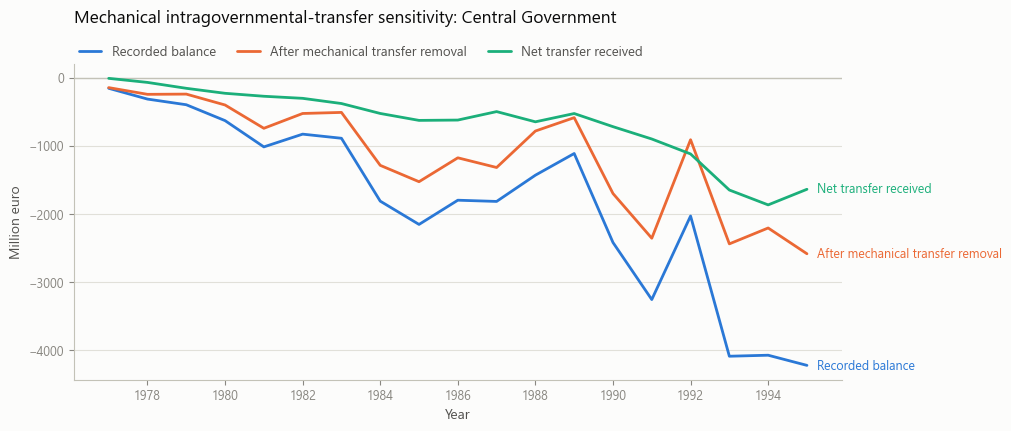

In [3]:
figure = figures.transfer_sensitivity(sensitivity, 'central_government')

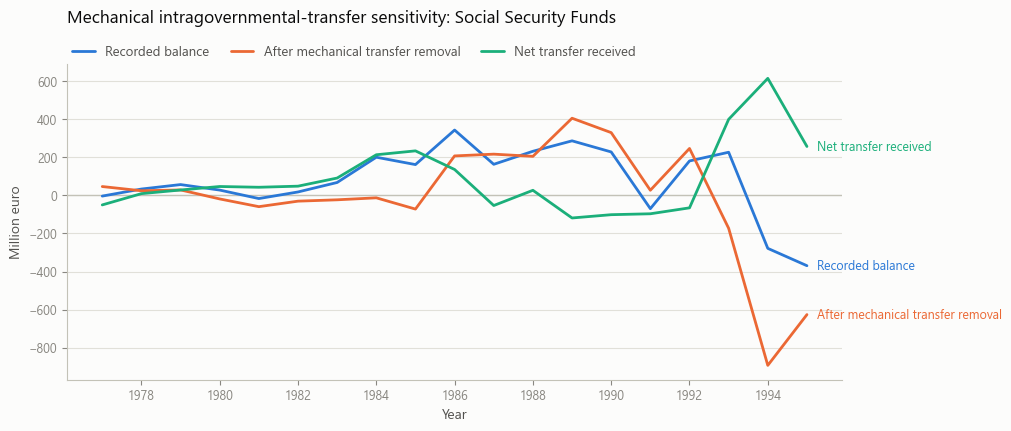

In [4]:
figure = figures.transfer_sensitivity(sensitivity, 'social_security_funds')

## 2. Scale of the operation

The table below reports, by sector, how large the net transfer is relative to the
recorded balance. A large ratio means the recorded location of the balance is
sensitive to the transfer convention, and nothing more.

In [5]:
scale = sensitivity.assign(
    transfer_share_abs_balance=(
        sensitivity['net_intragov_transfer_m_eur'].abs() / sensitivity['balance_m_eur'].abs()
    )
)
display(
    scale.groupby('sector')[['net_intragov_transfer_m_eur', 'transfer_share_abs_balance']]
    .agg(['mean', 'max'])
    .round(3)
)

net_intragov_transfer_m_eur           transfer_share_abs_balance        
                                                 mean       max                       mean     max
sector                                                                                            
central_government                           -671.345   -10.035                      0.348   0.551
regional_local_government                     583.987  1380.737                     13.353  48.834
social_security_funds                          87.357   614.644                      1.720  13.027

## Interpretation limits

1. This is **not a counterfactual**. A transfer usually finances an expenditure
   responsibility assigned to the recipient; removing the transfer while leaving
   the responsibility in place does not describe a coherent alternative world.
2. It is **not** an underlying or true balance, and it is never used to restate
   B.9 anywhere in this repository.
3. The calculation is available for **1977-1995 only**, because the modern source
   does not publish the same transfer breakdown.

---

[Previous: 09. Social Security Funds mechanisms](09_social_security_mechanisms.ipynb) | [Next: 11. Primary balance and interest](11_primary_balance.ipynb)

Every table shown above is also persisted as CSV, so results can be checked without reading notebook state. To rebuild everything from the bundled raw sources:

```bash
poetry install
make all
```